In [2]:
from plotnine import *
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as plt
from matplotlib.patches import Rectangle, Patch

In [3]:
models = ["nlmixr2", "Simwork", "Simwork_surrogate", "Sbml"]
folder = {
    "map": "Benchmark_Data_convergence",
    "runtime": "Benchmark_Data_Runtime",
    "VPC": "Benchmark_Data_VPC",
}


def data_path(model, kind):
    return Path(".") / folder[kind] / f"{model}_{kind}.csv"


Order = ["nlmixr2 (R)", "PySAEM\n(Simwork)", "PySAEM\n(Surrogate)", "PySAEM\n(SBML)"]

source_names = dict(zip(["nlmixr2", "Simwork", "Simwork_surrogate", "Sbml"], Order))

Colors = dict(zip(Order, ["#0072B2", "#D55E00", "#E69F00", "#009E73"]))


def canon_source(s):
    return pd.Categorical(
        pd.Series(s).map(lambda x: source_names.get(x, x)),
        categories=Order,
        ordered=True,
    )


figsize = (12, 12)

poster_theme = theme_bw(base_size=18) + theme(
    figure_size=figsize,
    plot_title=element_text(size=20, weight="bold"),
    legend_title=element_text(weight="bold"),
    panel_grid_minor=element_blank(),
    strip_background=element_rect(fill="#EDEDED", color="none"),
    strip_text=element_text(weight="bold"),
)

source_fill = scale_fill_manual(values=Colors, name="Source", limits=Order)
source_color = scale_color_manual(values=Colors, name="Source", limits=Order)

## Convergence benchmark data

In [4]:
params = ["CLint", "KbBR", "KbMU", "KbBO", "KbAD", "KbRB"]


def load_map(model):
    df = pd.read_csv(data_path(model, "map"))
    if "id_ref" in df.columns:
        df = df.rename(columns={"id_ref": "ID"})
    out = df[["ID"] + params].copy()
    out["algo"] = model
    return out


def process_map_data(models=models):
    map_df = pd.concat([load_map(m) for m in models], ignore_index=True)
    return map_df.melt(
        id_vars=["ID", "algo"], value_vars=params, var_name="descriptor"
    ).reset_index(drop=True)

In [5]:
map_obs = process_map_data()
display(map_obs.head())

,ID,algo,descriptor,value
0,793,nlmixr2,CLint,849.395462
1,794,nlmixr2,CLint,934.154950
2,795,nlmixr2,CLint,1361.743002
3,796,nlmixr2,CLint,1599.059268
4,797,nlmixr2,CLint,702.770778


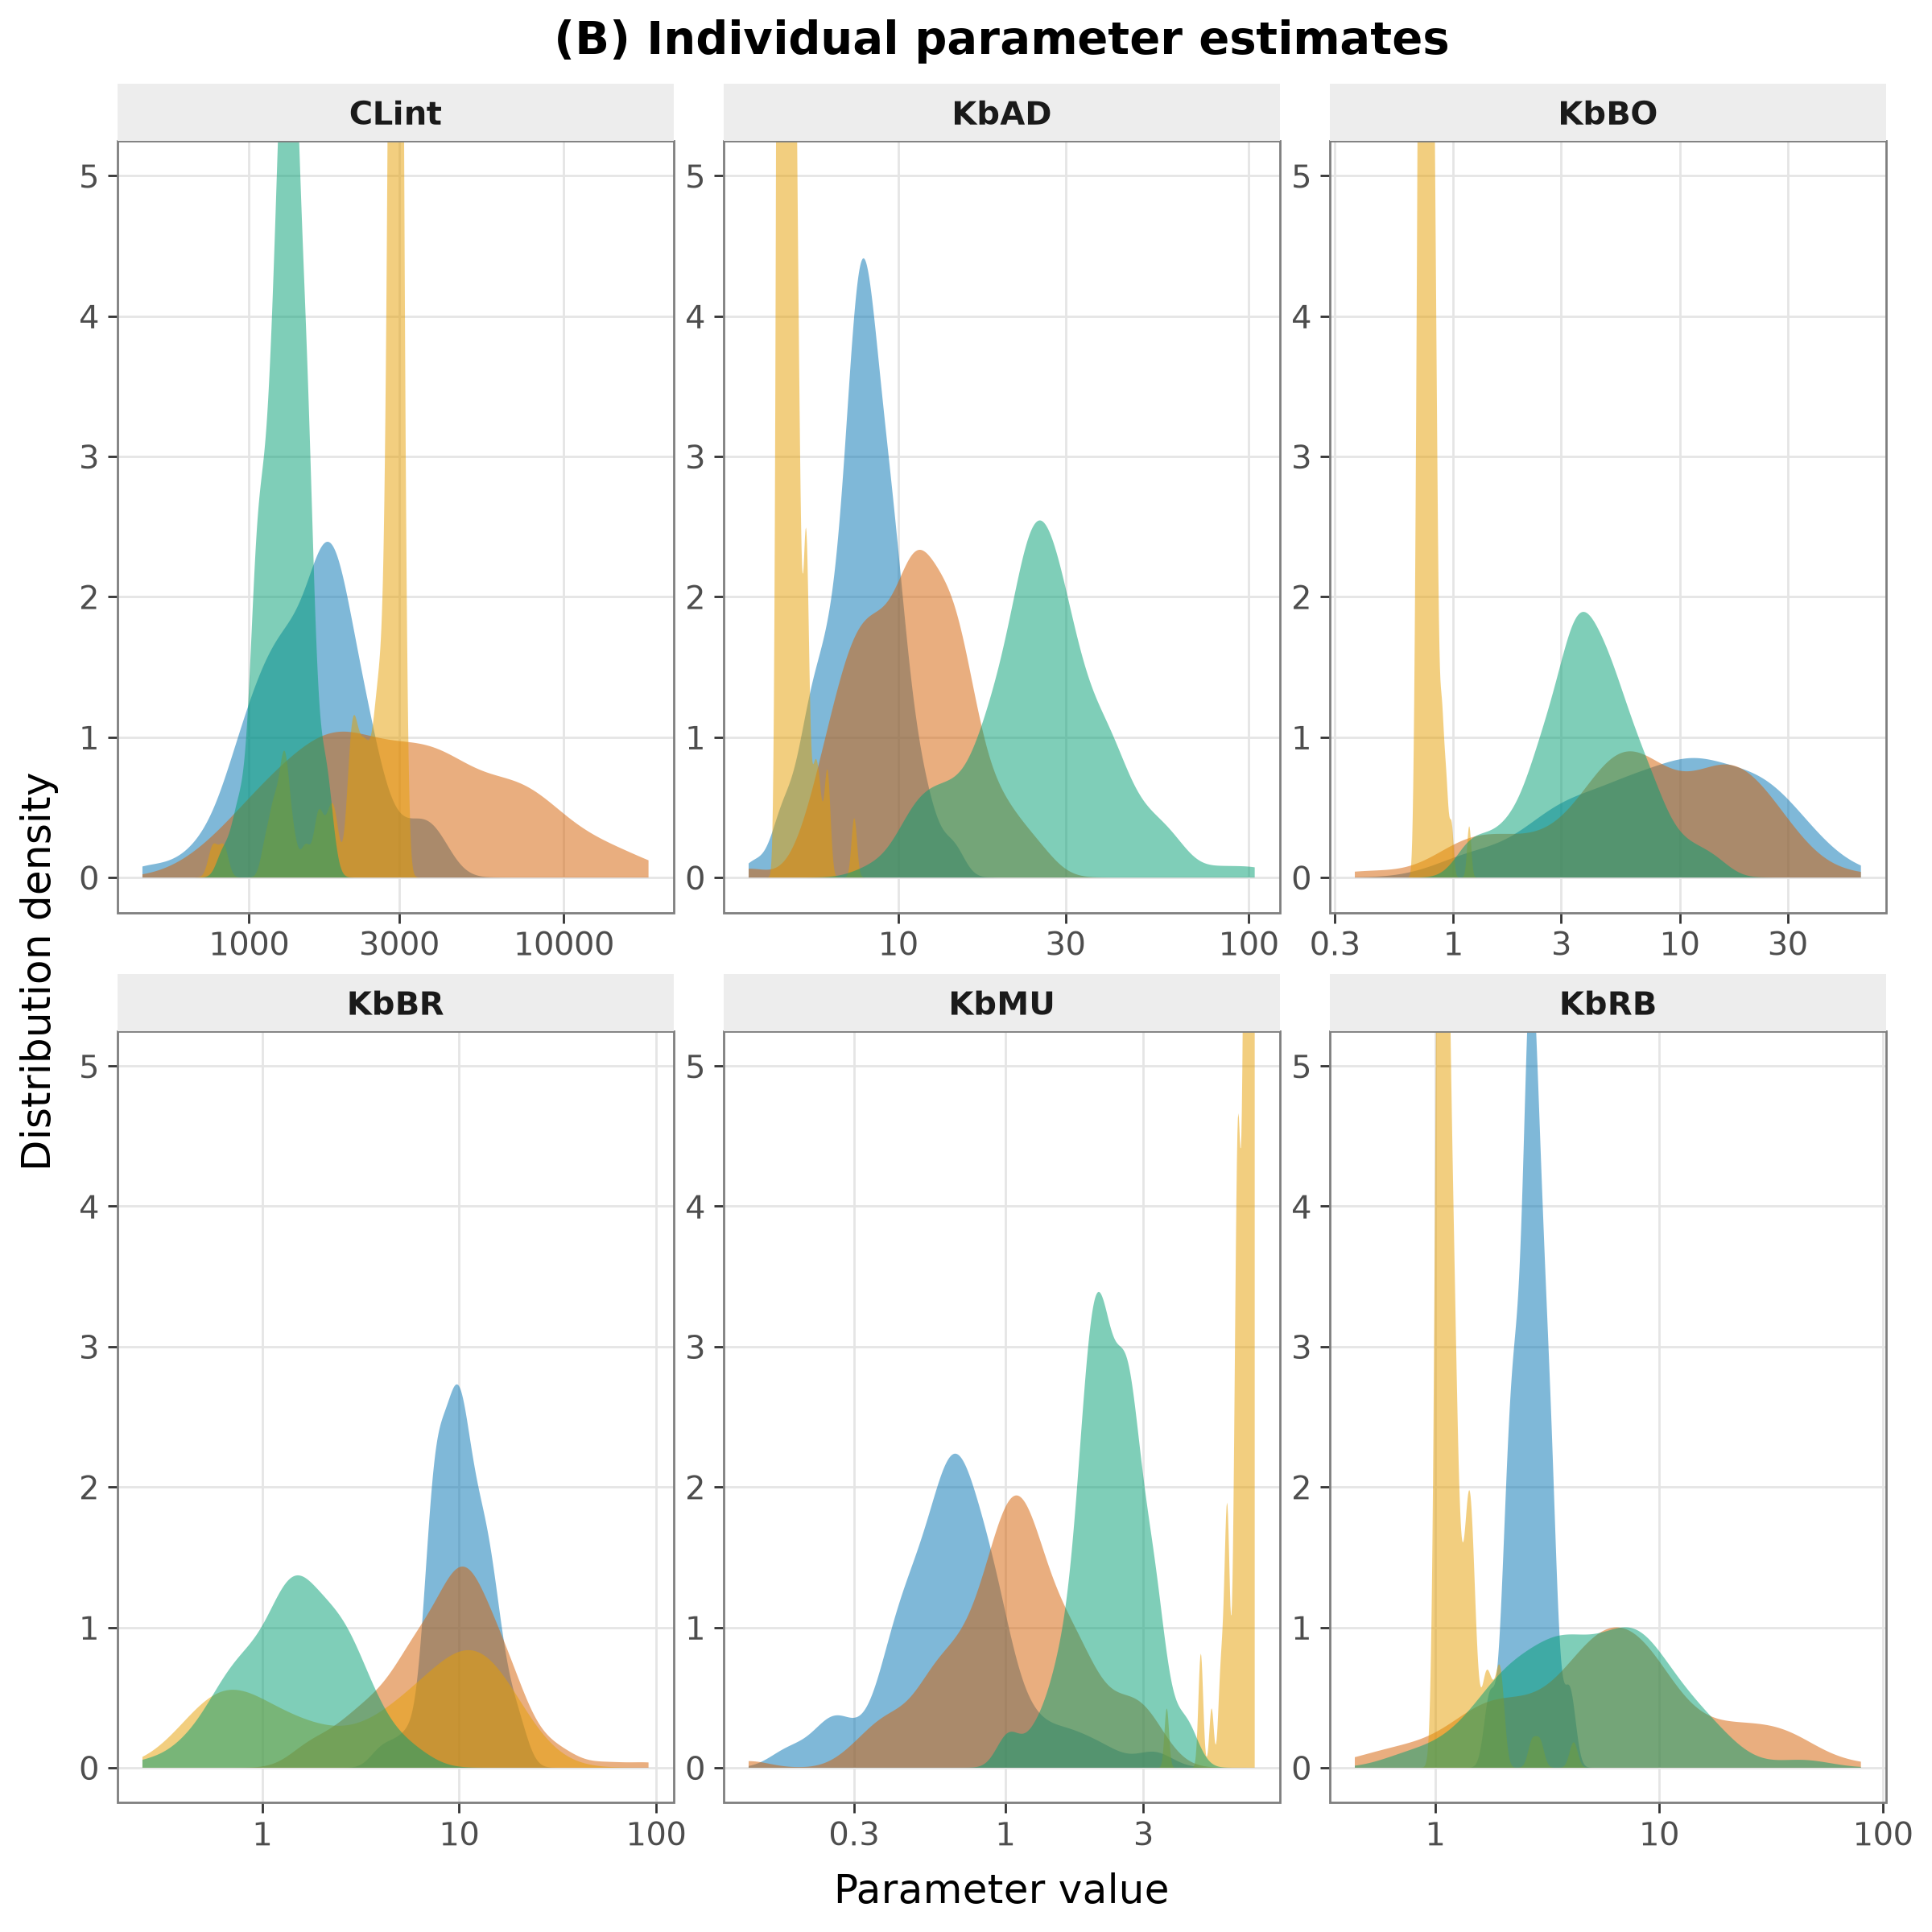

In [6]:
map_obs = map_obs.copy()
map_obs["Source"] = canon_source(map_obs["algo"])
map_obs["descriptor"] = pd.Categorical(
    map_obs["descriptor"],
    categories=["CLint", "KbAD", "KbBO", "KbBR", "KbMU", "KbRB"],
    ordered=True,
)

(
    ggplot(map_obs, aes(x="value", fill="Source"))
    + geom_density(alpha=0.5, color=None)
    + facet_wrap("~descriptor", ncol=3, scales="free")
    + scale_x_continuous(trans="log10")
    + coord_cartesian(ylim=(0, 5))
    + source_fill
    + labs(
        x="Parameter value",
        y="Distribution density",
        title="(B) Individual parameter estimates",
    )
    + poster_theme
    + theme(legend_position="none")
)

## Performance benchmark data

In [7]:
perf_nlmixr2 = (
    pd.read_csv(data_path("nlmixr2", "runtime"))[["time_sec"]]
    .rename(columns={"time_sec": "total_time"})
    .assign(algo="nlmixr2")
)
perf_Simwork = (
    pd.read_csv(data_path("Simwork", "runtime"))[["time_saem"]]
    .rename(columns={"time_saem": "total_time"})
    .assign(algo="Simwork")
)
perf_Sbml = (
    pd.read_csv(data_path("Sbml", "runtime"))[["time_saem"]]
    .rename(columns={"time_saem": "total_time"})
    .assign(algo="Sbml")
)
perf_Surrogate = pd.read_csv(data_path("Simwork_surrogate", "runtime"))[
    ["total_time"]
].assign(algo="Simwork_surrogate")

perf_df = pd.concat(
    [perf_nlmixr2, perf_Simwork, perf_Surrogate, perf_Sbml], ignore_index=True
)
perf_df["Source"] = canon_source(perf_df["algo"])

surrogate = pd.read_csv(data_path("Simwork_surrogate", "runtime"))

summary = (
    perf_df.groupby("Source", observed=True)["total_time"]
    .agg(med="median")
    .reset_index()
)
summary["label"] = summary["med"].map(lambda t: f"{t:.0f} s")

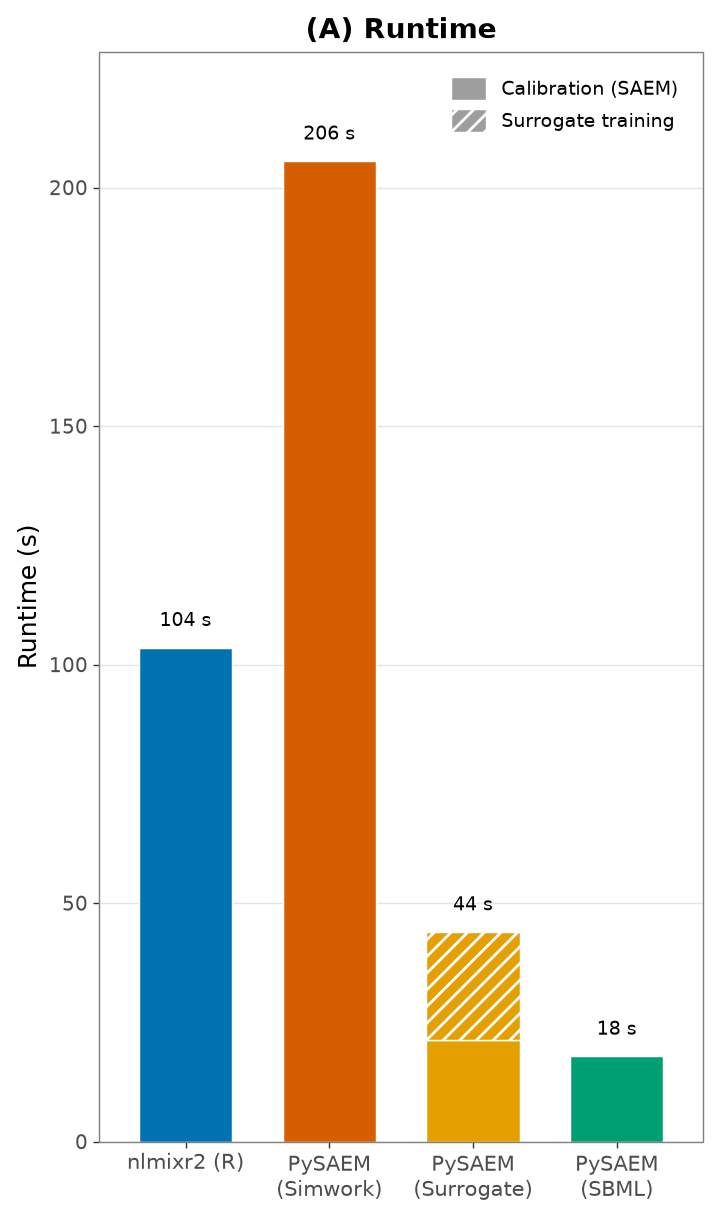

In [8]:
parts = pd.DataFrame(
    {
        "Source": pd.Categorical(
            [Order[0], Order[1], Order[2], Order[2], Order[3]],
            categories=Order,
            ordered=True,
        ),
        "phase": pd.Categorical(
            [
                "Calibration (SAEM)",
                "Calibration (SAEM)",
                "Surrogate training",
                "Calibration (SAEM)",
                "Calibration (SAEM)",
            ],
            categories=["Surrogate training", "Calibration (SAEM)"],
            ordered=True,
        ),
        "t": [
            summary.loc[summary.Source == Order[0], "med"].iloc[0],
            summary.loc[summary.Source == Order[1], "med"].iloc[0],
            surrogate["time_train"].median(),
            surrogate["time_saem"].median(),
            summary.loc[summary.Source == Order[3], "med"].iloc[0],
        ],
    }
)

plt.rcParams["hatch.linewidth"] = 2.0

training_time = surrogate["time_train"].median()

p = (
    ggplot(parts, aes(x="Source", y="t", fill="Source", alpha="phase"))
    + geom_col(width=0.65, color="white", size=0.6)
    + geom_text(
        summary,
        aes(x="Source", y="med", label="label"),
        inherit_aes=False,
        nudge_y=6,
        size=14,
    )
    + scale_y_continuous(expand=(0, 0, 0.08, 0))
    + scale_alpha_manual(
        values={"Surrogate training": 1.0, "Calibration (SAEM)": 1.0}, guide=None
    )
    + scale_fill_manual(values=Colors, limits=Order, guide=None)
    + labs(x="", y="Runtime (s)", title="(A) Runtime")
    + poster_theme
    + theme(
        figure_size=(7, 12),
        axis_text_x=element_text(size=15),
        panel_grid_major_x=element_blank(),
    )
)

fig = p.draw()
ax = fig.axes[0]

for path in ax.collections[0].get_paths():
    v = path.vertices
    x0, x1 = v[:, 0].min(), v[:, 0].max()
    y0, y1 = v[:, 1].min(), v[:, 1].max()
    if abs((y1 - y0) - training_time) < 1e-6:
        ax.add_patch(
            Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                facecolor="none",
                edgecolor="white",
                hatch="//",
                linewidth=0,
                zorder=3,
            )
        )

handles = [
    Patch(facecolor="#9E9E9E", edgecolor="white"),
    Patch(facecolor="#9E9E9E", edgecolor="white", hatch="//"),
]
ax.legend(
    handles,
    ["Calibration (SAEM)", "Surrogate training"],
    loc="upper right",
    frameon=False,
    fontsize=14,
    handlelength=1.8,
    handleheight=1.4,
    borderpad=0.8,
)

fig

## VPC Benchmark Data

In [9]:
VPC_nlmixr2 = pd.read_csv(data_path("nlmixr2", "VPC"))
VPC_Simwork = pd.read_csv(data_path("Simwork", "VPC"))
VPC_Sbml = pd.read_csv(data_path("Sbml", "VPC"))
VPC_Surrogate = pd.read_csv(data_path("Simwork_surrogate", "VPC"))

for df in (VPC_Simwork, VPC_Sbml, VPC_Surrogate):
    df["bin_center"] = df["bin_center"] / 3600.0

VPC_nlmixr2["model"] = "nlmixr2"
VPC_Simwork["model"] = "Simwork"
VPC_Sbml["model"] = "Sbml"
VPC_Surrogate["model"] = "Simwork_surrogate"

vpc_data = pd.concat(
    [VPC_nlmixr2, VPC_Simwork, VPC_Sbml, VPC_Surrogate], ignore_index=True
)

for c in ["q_obs", "pred_median", "pred_lower", "pred_upper"]:
    vpc_data[c] = np.exp(vpc_data[c])

vpc_data["model"] = pd.Categorical(vpc_data["model"], categories=models, ordered=True)

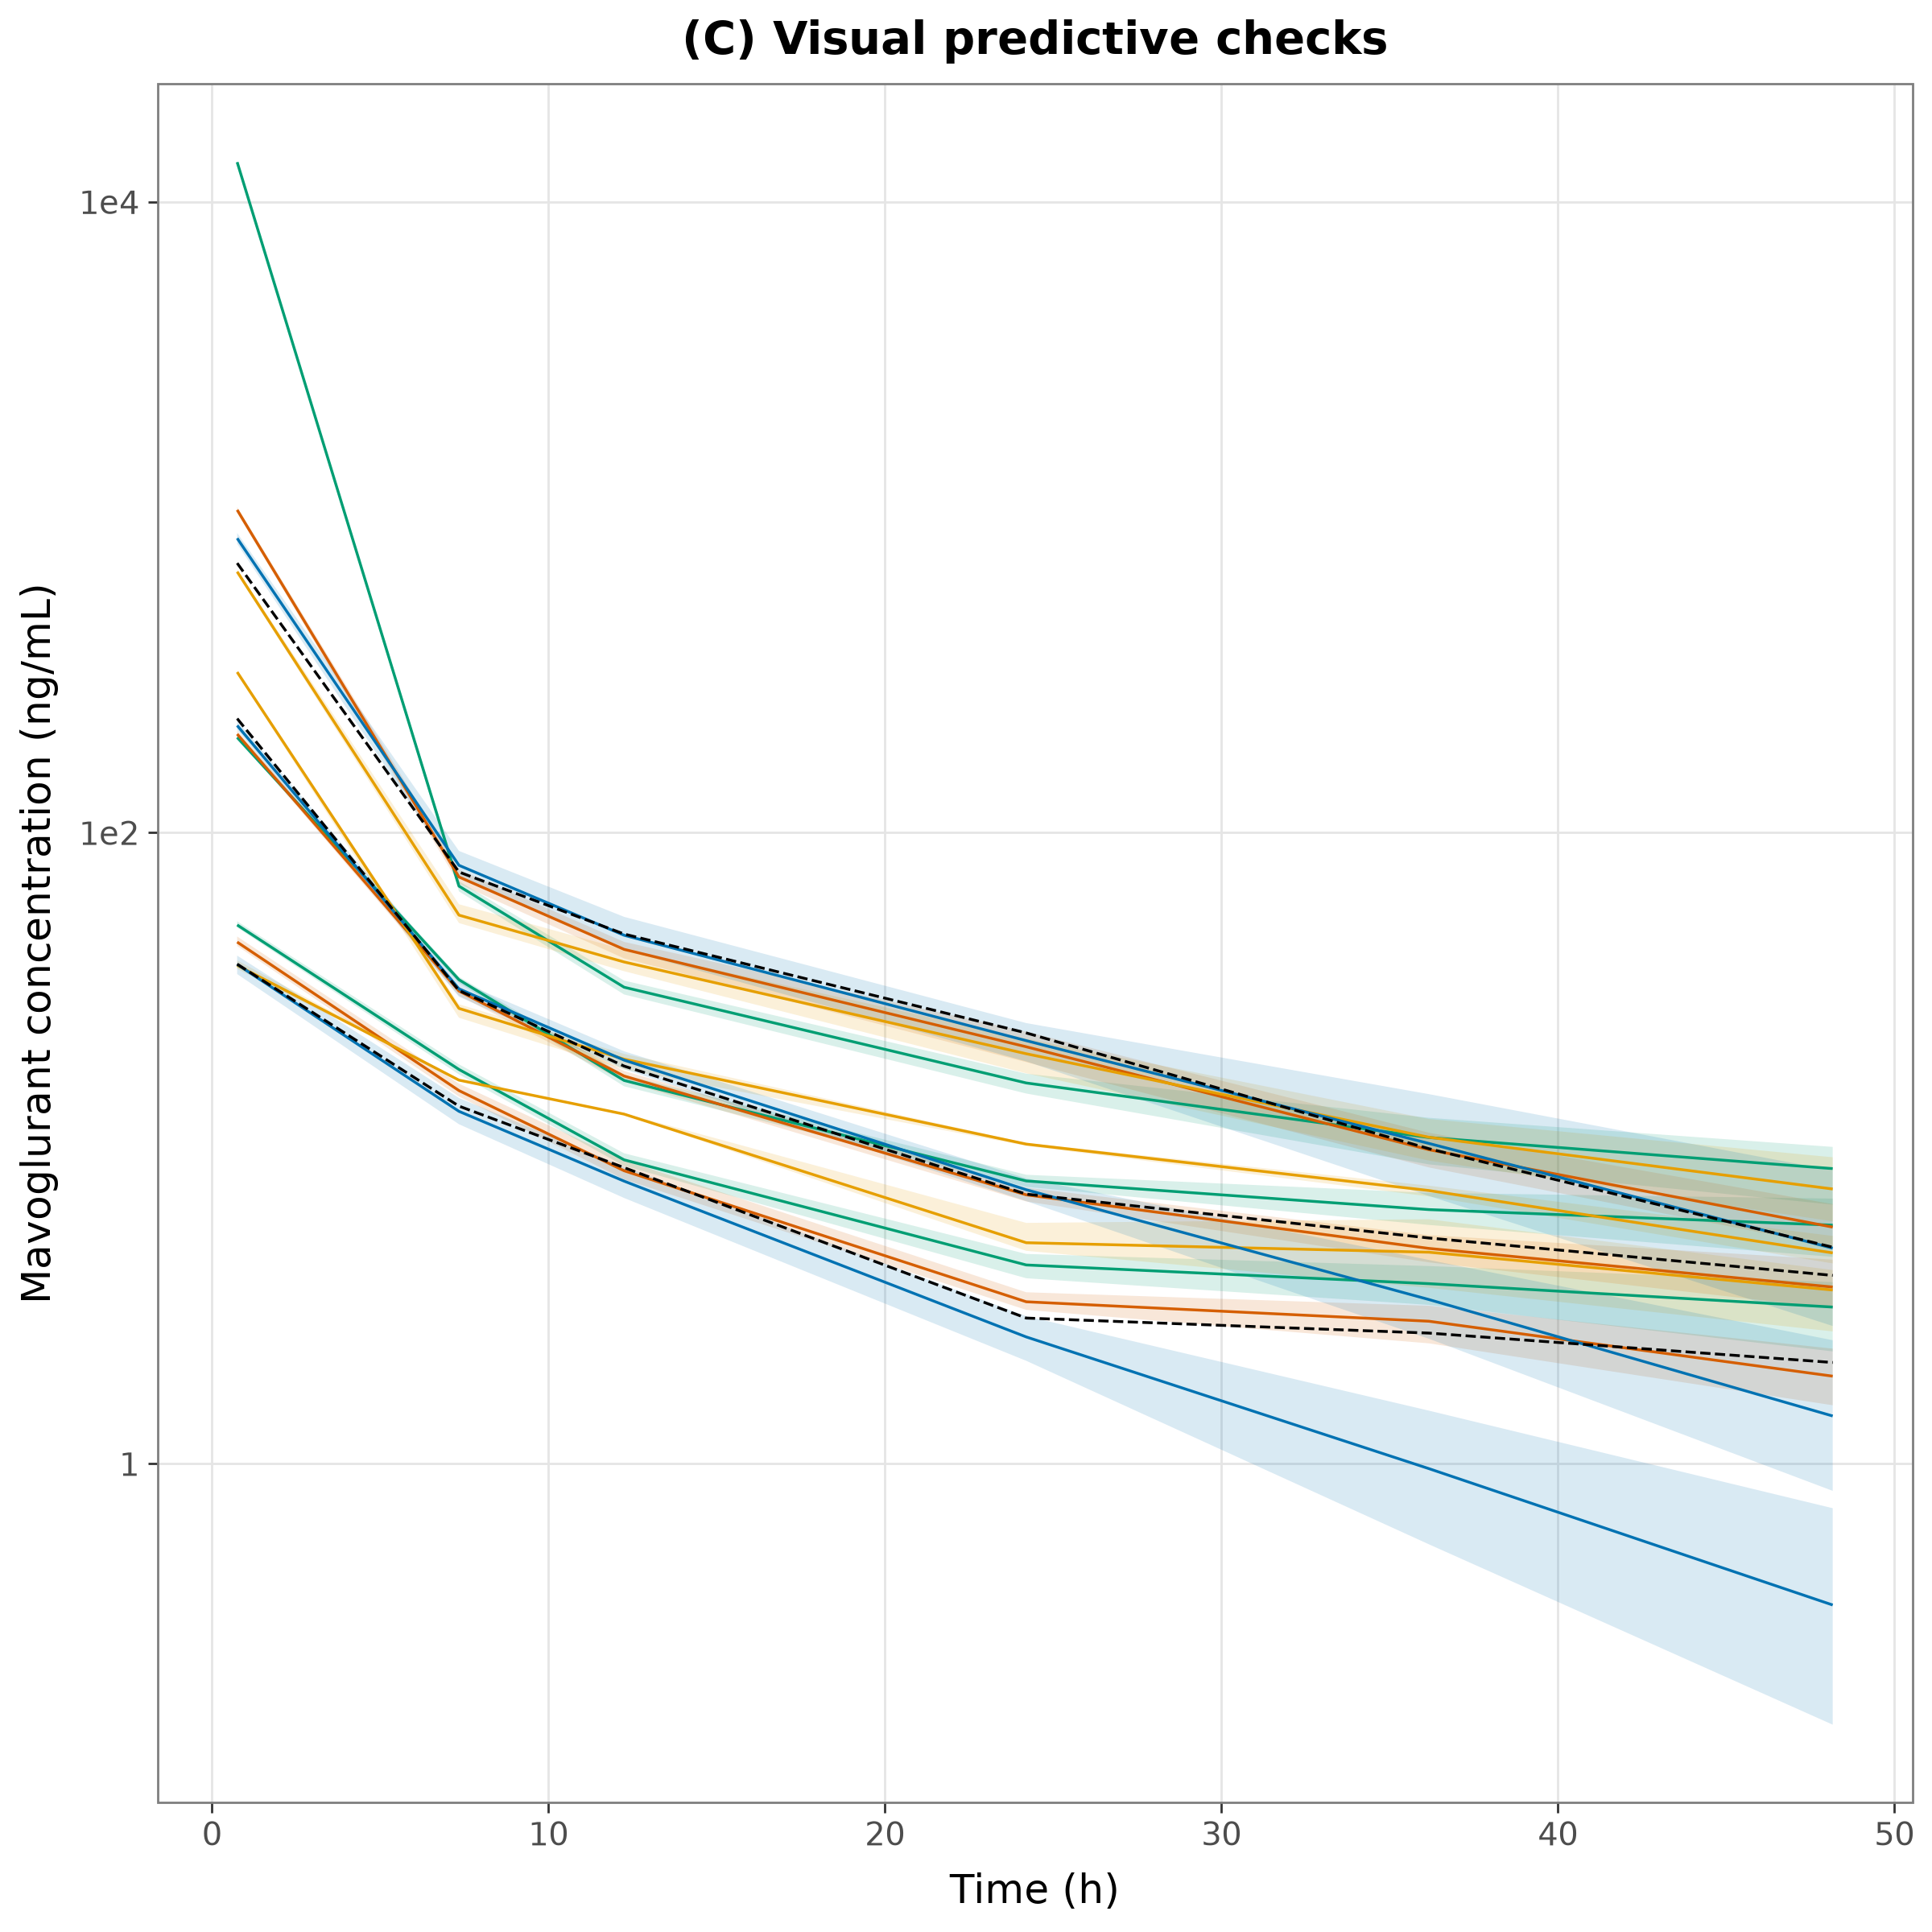

In [10]:
vpc_data = vpc_data.copy()
vpc_data["Source"] = canon_source(vpc_data["model"])
vpc_data["grp"] = (
    vpc_data["Source"].astype(str) + "|" + vpc_data["quantile"].astype(str)
)

pred = vpc_data.assign(value=vpc_data["pred_median"])
pred["grp"] = pred["Source"].astype(str) + "|" + pred["quantile"].astype(str)

obs = vpc_data[vpc_data["model"] == "nlmixr2"].assign(value=lambda d: d["q_obs"])
obs["grp"] = "obs|" + obs["quantile"].astype(str)

(
    ggplot()
    + geom_ribbon(
        vpc_data,
        aes(
            x="bin_center",
            ymin="pred_lower",
            ymax="pred_upper",
            fill="Source",
            group="grp",
        ),
        alpha=0.15,
    )
    + geom_line(
        pred, aes(x="bin_center", y="value", color="Source", group="grp"), size=0.7
    )
    + geom_line(
        obs,
        aes(x="bin_center", y="value", group="grp"),
        color="black",
        linetype="dashed",
        size=0.7,
    )
    + source_color
    + source_fill
    + scale_y_log10()
    + labs(
        x="Time (h)",
        y="Mavoglurant concentration (ng/mL)",
        title="(C) Visual predictive checks",
    )
    + poster_theme
    + theme(legend_position="none")
)

In [11]:
handles = [Rectangle((0, 0), 1, 1, color=Colors[s]) for s in Order]
fig, ax = plt.subplots(figsize=(2, figsize[1]))
ax.axis("off")
ax.legend(
    handles,
    Order,
    title="Source",
    ncol=1,
    loc="center",
    frameon=False,
    title_fontproperties={"weight": "bold", "size": 18},
    fontsize=16,
)
fig

AttributeError: module 'matplotlib' has no attribute 'subplots'